In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from IPython.display import display

from src.data.eda import load_processed_dataset
from src.data.io import load_mask
from src.split.spatial import make_stratified_spatial_split, save_spatial_split
from src.split.export_tabular import export_train_test_split

In [2]:
MAIN_DIR = Path("/home/dani/github/profecia/data")

PROCESSED_BASE_DIR = MAIN_DIR / "processed"
MASKS_DIR = MAIN_DIR / "masks"
SPLITS_BASE_DIR = MAIN_DIR / "splits"

VARIABLE_NAMES = ["LAI", "SM1", "SM2", "TP", "T2M", "SSRD", "VPD"]
PREDICTOR_NAMES = ["SM1", "SM2", "TP", "T2M", "SSRD", "VPD"]

processed_run_name = "land_ebf_bs_annual"   # ejemplo: "land_ebf_bs_monthly"
split_mask_name = "landcover"                # "climate" o "landcover"

pixel_fraction = 0.3
test_fraction = 0.10
min_valid_fraction = 0.0

seed = 42
subset_seed = 42

PROCESSED_DIR = PROCESSED_BASE_DIR / processed_run_name
SPLIT_DIR = SPLITS_BASE_DIR / processed_run_name / split_mask_name

print("PROCESSED_DIR:", PROCESSED_DIR)
print("SPLIT_DIR:", SPLIT_DIR)

PROCESSED_DIR: /home/dani/github/profecia/data/processed/land_ebf_bs_annual
SPLIT_DIR: /home/dani/github/profecia/data/splits/land_ebf_bs_annual/landcover


In [3]:
with open(MASKS_DIR / "mask_metadata.json", "r", encoding="utf-8") as f:
    mask_metadata = json.load(f)

labels_raw = mask_metadata["masks"][split_mask_name]["labels"]
LABELS = {int(k): v for k, v in labels_raw.items()}

print("split_mask_name:", split_mask_name)
print("labels:", LABELS)

split_mask_name: landcover
labels: {0: 'NoData', 10: 'Cropland', 20: 'Forest', 30: 'Grassland', 40: 'Shrubland', 70: 'Tundra', 90: 'Barren land', 100: 'Snow/Ice'}


## Cargar dataset procesado

In [4]:
data_dict, metadata = load_processed_dataset(
    input_dir=PROCESSED_DIR,
    variable_names=VARIABLE_NAMES,
    reference_variable="LAI",
)

lai = data_dict["LAI"]
predictors = {name: data_dict[name] for name in PREDICTOR_NAMES}

print("Variables cargadas:", list(data_dict.keys()))
print("Shape LAI:", lai.shape)
print("Dims LAI:", lai.dims)
print("Periodo:", str(lai.time.min().values)[:10], "->", str(lai.time.max().values)[:10])
print("Lat:", float(lai.latitude.min()), "->", float(lai.latitude.max()))
print("Lon:", float(lai.longitude.min()), "->", float(lai.longitude.max()))

Variables cargadas: ['LAI', 'SM1', 'SM2', 'TP', 'T2M', 'SSRD', 'VPD']
Shape LAI: (41, 360, 720)
Dims LAI: ('time', 'latitude', 'longitude')
Periodo: 1982-01-01 -> 2022-01-01
Lat: -90.0 -> 89.5
Lon: -180.0 -> 179.5


## Cargar máscara

In [5]:
category_mask = load_mask(
    mask_dir=MASKS_DIR,
    mask_name=split_mask_name,
    latitude=lai.latitude.values,
    longitude=lai.longitude.values,
)

print(category_mask)
print("Clases presentes:", np.unique(category_mask.values[~np.isnan(category_mask.values)]).astype(int))

<xarray.DataArray 'landcover' (latitude: 360, longitude: 720)> Size: 259kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(360, 720), dtype=uint8)
Coordinates:
  * latitude   (latitude) float32 1kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
Clases presentes: [  0  10  20  30  40  70  90 100]


## Crear split espacial estratificado

In [6]:
split_result = make_stratified_spatial_split(
    lai=lai,
    category_mask=category_mask,
    test_fraction=test_fraction,
    seed=seed,
    ignore_codes=(0,),
    split_name="30pct_pixel_fraction",
    category_labels=LABELS,
    pixel_fraction=pixel_fraction,
    subset_seed=subset_seed,
    min_valid_fraction=min_valid_fraction,
)

train_mask = split_result["train_mask"]
test_mask = split_result["test_mask"]
selected_pixel_mask = split_result["selected_pixel_mask"]
eligible_pixel_mask = split_result["eligible_pixel_mask"]
valid_pixel_mask = split_result["valid_pixel_mask"]
split_metadata = split_result["metadata"]

In [7]:
subset_summary_df = pd.DataFrame(split_metadata["pixel_subset_per_category"])
split_summary_df = pd.DataFrame(split_metadata["split_per_category"])

print("=== Pixel subset per category ===")
display(subset_summary_df)

print("=== Train/Test split per category ===")
display(split_summary_df)

=== Pixel subset per category ===


,category_code,category_label,n_eligible,n_selected,n_dropped,pixel_fraction_real
0,10,Cropland,5498,1649,3849,0.299927
1,20,Forest,14272,4282,9990,0.300028
2,30,Grassland,11021,3306,7715,0.299973
3,40,Shrubland,6071,1821,4250,0.299951
4,70,Tundra,4880,1464,3416,0.300000
5,90,Barren land,6457,1937,4520,0.299985
6,100,Snow/Ice,441,132,309,0.299320


=== Train/Test split per category ===


,category_code,category_label,n_selected,n_test,n_train,test_fraction_real
0,10,Cropland,1649,165,1484,0.100061
1,20,Forest,4282,428,3854,0.099953
2,30,Grassland,3306,331,2975,0.100121
3,40,Shrubland,1821,182,1639,0.099945
4,70,Tundra,1464,146,1318,0.099727
5,90,Barren land,1937,194,1743,0.100155
6,100,Snow/Ice,132,13,119,0.098485


In [8]:
assert train_mask.shape == (lai.sizes["latitude"], lai.sizes["longitude"])
assert test_mask.shape == (lai.sizes["latitude"], lai.sizes["longitude"])

assert not np.any(train_mask.values & test_mask.values), "Train y test no deben solaparse"

covered = train_mask.values | test_mask.values
selected = selected_pixel_mask.values.astype(bool)

assert np.array_equal(covered, selected), "Train + test no cubren exactamente los píxeles seleccionados"

print("Split correcto")
print("Selected pixels:", int(selected.sum()))
print("Train pixels   :", int(train_mask.values.sum()))
print("Test pixels    :", int(test_mask.values.sum()))

Split correcto
Selected pixels: 14591
Train pixels   : 13132
Test pixels    : 1459


## Guardar máscaras y metadata del split

In [9]:
save_spatial_split(
    output_dir=SPLIT_DIR,
    train_mask=train_mask,
    test_mask=test_mask,
    metadata=split_metadata,
    prefix=split_mask_name,
    selected_pixel_mask=selected_pixel_mask,
    eligible_pixel_mask=eligible_pixel_mask,
    valid_pixel_mask=valid_pixel_mask,
)

print("Split guardado en:", SPLIT_DIR)

Split guardado en: /home/dani/github/profecia/data/splits/land_ebf_bs_annual/landcover


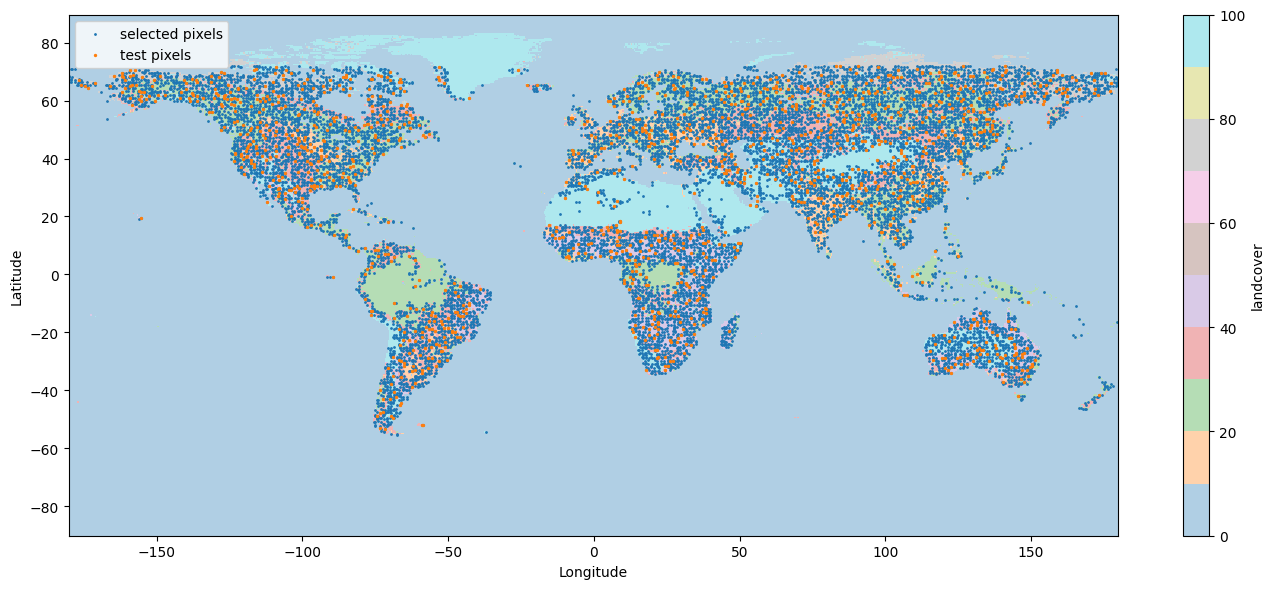

In [10]:
plt.figure(figsize=(14, 6))

category_mask.plot(
    x="longitude",
    y="latitude",
    cmap="tab10",
    alpha=0.35,
    add_colorbar=True,
)

sel_lat_idx, sel_lon_idx = np.where(selected_pixel_mask.values)
sel_lats = selected_pixel_mask.latitude.values[sel_lat_idx]
sel_lons = selected_pixel_mask.longitude.values[sel_lon_idx]

test_lat_idx, test_lon_idx = np.where(test_mask.values)
test_lats = test_mask.latitude.values[test_lat_idx]
test_lons = test_mask.longitude.values[test_lon_idx]

plt.scatter(sel_lons, sel_lats, s=1, label="selected pixels")
plt.scatter(test_lons, test_lats, s=2, label="test pixels")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

## Exportar train/test tabular

In [11]:
dataset_metadata = export_train_test_split(
    target=lai,
    predictors=predictors,
    train_mask=train_mask,
    test_mask=test_mask,
    output_dir=SPLIT_DIR,
    prefix=f"{processed_run_name}_{split_mask_name}_{"30pct_pixel_fraction"}",
    lat_block_size=10,
)

dataset_metadata

{'prefix': 'land_ebf_bs_annual_landcover_30pct_pixel_fraction',
 'n_train': 538412,
 'n_test': 59819,
 'n_features': 6,
 'feature_names': ['SM1', 'SM2', 'TP', 'T2M', 'SSRD', 'VPD'],
 'target': 'LAI',
 'target_dtype': 'float32',
 'feature_dtypes': {'SM1': 'float32',
  'SM2': 'float32',
  'TP': 'float32',
  'T2M': 'float32',
  'SSRD': 'float32',
  'VPD': 'float32'},
 'n_time': 41,
 'time_start': '1982-01-01 00:00:00',
 'time_end': '2022-01-01 00:00:00',
 'time_values': ['1982-01-01 00:00:00',
  '1983-01-01 00:00:00',
  '1984-01-01 00:00:00',
  '1985-01-01 00:00:00',
  '1986-01-01 00:00:00',
  '1987-01-01 00:00:00',
  '1988-01-01 00:00:00',
  '1989-01-01 00:00:00',
  '1990-01-01 00:00:00',
  '1991-01-01 00:00:00',
  '1992-01-01 00:00:00',
  '1993-01-01 00:00:00',
  '1994-01-01 00:00:00',
  '1995-01-01 00:00:00',
  '1996-01-01 00:00:00',
  '1997-01-01 00:00:00',
  '1998-01-01 00:00:00',
  '1999-01-01 00:00:00',
  '2000-01-01 00:00:00',
  '2001-01-01 00:00:00',
  '2002-01-01 00:00:00',
  '2

## Revisar arrays exportados

In [12]:
X_train = np.load(SPLIT_DIR / "X_train.npy", mmap_mode="r")
y_train = np.load(SPLIT_DIR / "y_train.npy", mmap_mode="r")

X_test = np.load(SPLIT_DIR / "X_test.npy", mmap_mode="r")
y_test = np.load(SPLIT_DIR / "y_test.npy", mmap_mode="r")

pixel_id_test = np.load(SPLIT_DIR / "pixel_id_test.npy", mmap_mode="r")
lat_idx_test = np.load(SPLIT_DIR / "lat_idx_test.npy", mmap_mode="r")
lon_idx_test = np.load(SPLIT_DIR / "lon_idx_test.npy", mmap_mode="r")
time_idx_test = np.load(SPLIT_DIR / "time_idx_test.npy", mmap_mode="r")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("pixel_id_test:", pixel_id_test.shape)
print("lat_idx_test :", lat_idx_test.shape)
print("lon_idx_test :", lon_idx_test.shape)
print("time_idx_test:", time_idx_test.shape)

X_train: (538412, 6)
y_train: (538412,)
X_test : (59819, 6)
y_test : (59819,)
pixel_id_test: (59819,)
lat_idx_test : (59819,)
lon_idx_test : (59819,)
time_idx_test: (59819,)


In [13]:
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]

assert X_test.shape[0] == pixel_id_test.shape[0]
assert X_test.shape[0] == lat_idx_test.shape[0]
assert X_test.shape[0] == lon_idx_test.shape[0]
assert X_test.shape[0] == time_idx_test.shape[0]

assert X_train.shape[1] == len(PREDICTOR_NAMES)
assert X_test.shape[1] == len(PREDICTOR_NAMES)

print("Arrays exportados consistentes")

Arrays exportados consistentes


In [14]:
print("NaN X_train:", np.isnan(X_train).sum())
print("NaN y_train:", np.isnan(y_train).sum())

print("NaN X_test :", np.isnan(X_test).sum())
print("NaN y_test :", np.isnan(y_test).sum())

assert np.isnan(X_train).sum() == 0
assert np.isnan(y_train).sum() == 0
assert np.isnan(X_test).sum() == 0
assert np.isnan(y_test).sum() == 0

print("No hay NaN en los arrays exportados")

NaN X_train: 0
NaN y_train: 0
NaN X_test : 0
NaN y_test : 0
No hay NaN en los arrays exportados
